In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv("Titanic-Dataset.csv",usecols=['Age','Fare','Survived'])

In [4]:
df.dropna(inplace=True)

In [5]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [7]:
df.shape

(714, 3)

In [8]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
X_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [11]:
clf = DecisionTreeClassifier()

In [12]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [13]:
accuracy_score(y_test,y_pred)

0.6433566433566433

In [14]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

0.6345266040688575

In [55]:
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [56]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1]),
])

In [57]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [58]:
trf.named_transformers_['first'].n_bins_

array([15])

In [59]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [60]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare_trf':X_train_trf[:,1]
})

In [61]:
output['age_labels'] = pd.cut(x = X_train['Age'],
                              bins=trf.named_transformers_['first'].bin_edges_[0].tolist())

output['fare_labels'] = pd.cut(x = X_train['Fare'],
                               bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [62]:
output.sample(5)

,age,age_trf,fare_trf,age_labels,fare_labels
865,42.0,12.0,6.0,"(38.0, 42.0]","(10.5, 13.0]"
143,19.0,3.0,0.0,"(16.0, 19.0]","(0.0, 7.25]"
14,14.0,1.0,2.0,"(6.0, 16.0]","(7.775, 7.896]"
34,28.0,7.0,13.0,"(25.0, 28.0]","(76.292, 108.9]"
103,33.0,9.0,4.0,"(32.0, 35.0]","(8.158, 10.5]"


In [63]:
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [64]:
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [65]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

0.6400821596244131

In [66]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()

c:\Users\IRVINEi\miniconda3\envs\polynominal_regression\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\IRVINEi\miniconda3\envs\polynominal_regression\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


0.6316901408450704


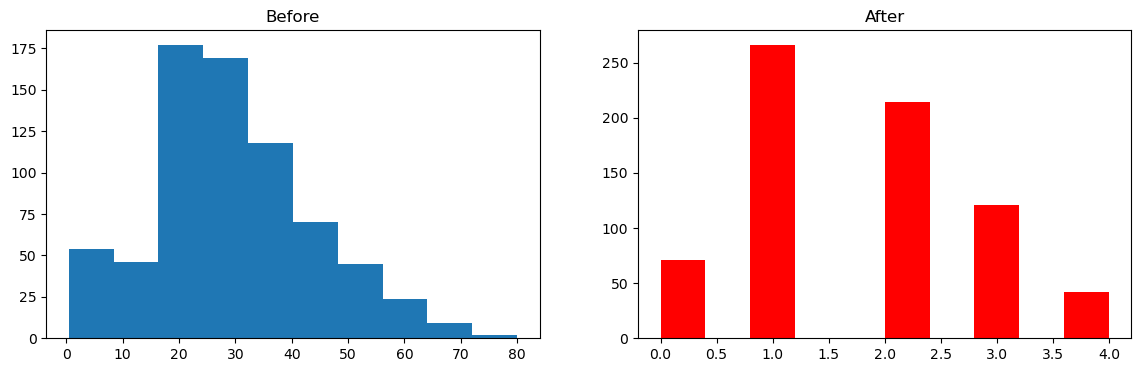

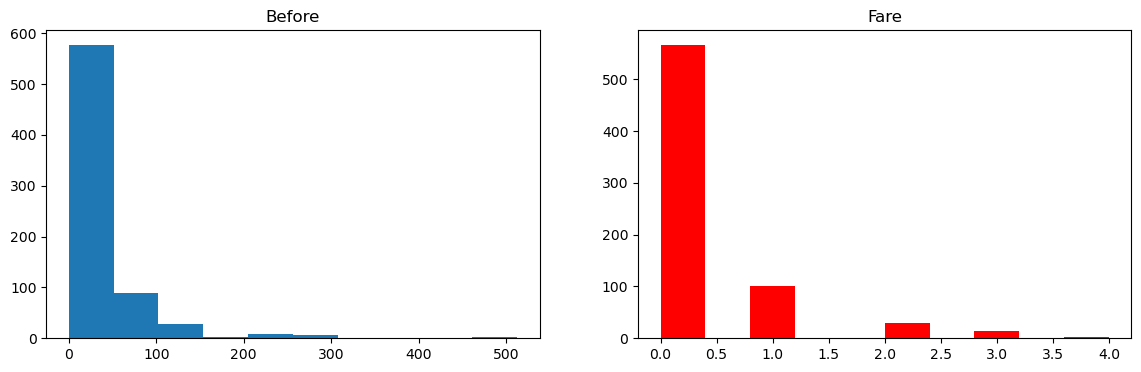

In [67]:
discretize(5,'kmeans')

0.6330790297339592


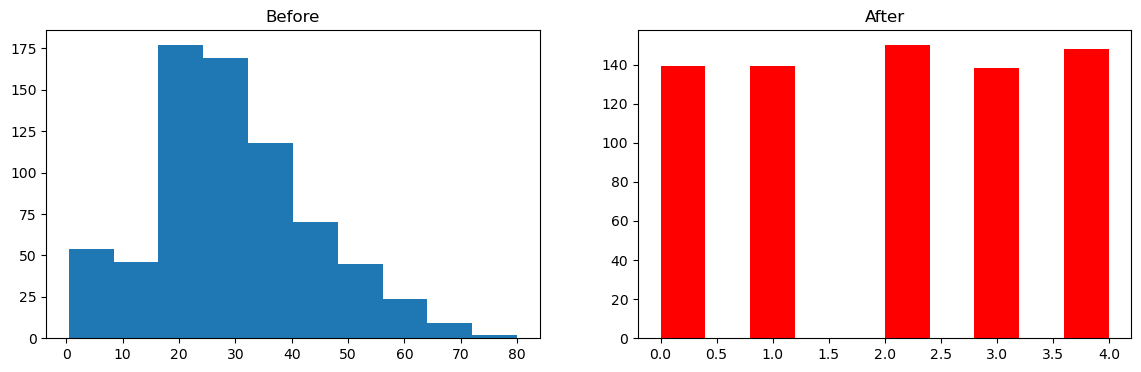

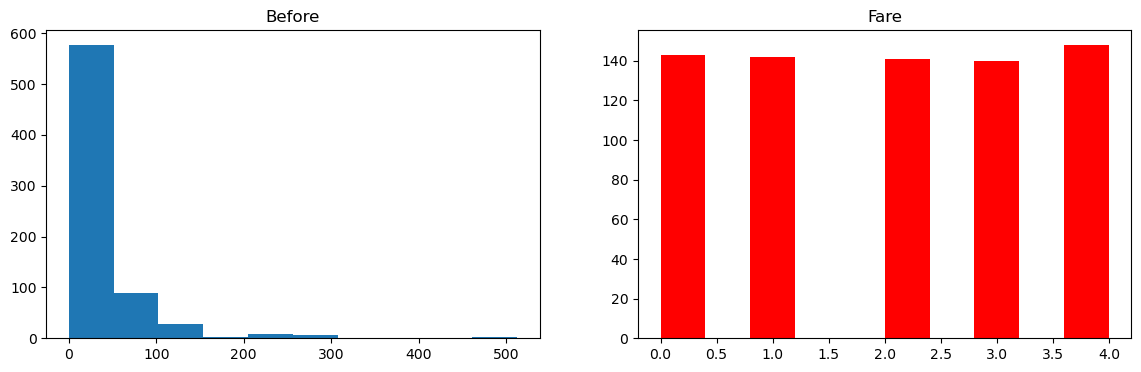

In [68]:
discretize(5,'quantile')

## Binarization

In [69]:
df = pd.read_csv("Titanic-Dataset.csv",usecols=['Age','Fare','SibSp','Parch','Survived'])

In [70]:
df['family'] = df['SibSp'] + df['Parch']

In [71]:
df.head()

,Survived,Age,SibSp,Parch,Fare,family
0,0,22.0,1,0,7.2500,1
1,1,38.0,1,0,71.2833,1
2,1,26.0,0,0,7.9250,0
3,1,35.0,1,0,53.1000,1
4,0,35.0,0,0,8.0500,0


In [72]:
df.drop(columns=['SibSp','Parch'],inplace=True)

In [73]:
df.head()

,Survived,Age,Fare,family
0,0,22.0,7.2500,1
1,1,38.0,71.2833,1
2,1,26.0,7.9250,0
3,1,35.0,53.1000,1
4,0,35.0,8.0500,0


In [74]:
df['family'].unique()

array([ 1,  0,  4,  2,  6,  5,  3,  7, 10], dtype=int64)

In [75]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [76]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [77]:
X_train.head()

,Age,Fare,family
331,45.5,28.5000,0
733,23.0,13.0000,0
382,32.0,7.9250,0
704,26.0,7.8542,1
813,6.0,31.2750,6


In [78]:
# without binarization

clf = DecisionTreeClassifier()

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

accuracy_score(y_test,y_pred)

0.6536312849162011

In [79]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

0.64645443196005

In [80]:
# Applying Binarization

from sklearn.preprocessing import Binarizer

In [82]:
trf = ColumnTransformer([
    ("bin",Binarizer(copy=False),['family'])
],remainder='passthrough')

In [83]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [84]:
pd.DataFrame(X_train_trf,columns=['family','Age','Fare'])

,family,Age,Fare
0,0.0,45.5,28.5000
1,0.0,23.0,13.0000
2,0.0,32.0,7.9250
3,1.0,26.0,7.8542
4,1.0,6.0,31.2750
...,...,...,...
707,0.0,21.0,7.6500
708,0.0,NaN,31.0000
709,1.0,41.0,14.1083
710,1.0,14.0,120.0000


In [85]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

accuracy_score(y_test,y_pred2)

0.6368715083798883

In [86]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X_trf,y,cv=10,scoring='accuracy'))

0.6543570536828963